<a href="https://colab.research.google.com/github/IsaacGSolis/Mineria-de-Datos-IEGS/blob/main/RegresionLinealE3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
datos=pd.read_csv('PracticaExamenes.csv')
datos.head()

,horas,puntuacion
0,3,64
1,4,67
2,6,76
3,3,65
4,5,72


In [15]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   horas       150 non-null    int64
 1   puntuacion  150 non-null    int64
dtypes: int64(2)
memory usage: 2.5 KB


In [16]:
datos.describe()

,horas,puntuacion
count,150.000000,150.000000
mean,3.513333,65.360000
std,1.759868,9.277439
min,1.000000,50.000000
25%,2.000000,58.000000
50%,4.000000,66.000000
75%,5.000000,73.000000
max,6.000000,80.000000


In [17]:
X=datos[['horas']].values
Y=datos[['puntuacion']].values

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [19]:
modelo = LinearRegression()
modelo.fit(X_train, Y_train)

LinearRegression()

In [20]:
pendiente=modelo.coef_[0][0]
intercepto=modelo.intercept_[0]
print("Pendiente:", pendiente)
print("Intercepto:", intercepto)

Pendiente: 5.173237753882916
Intercepto: 47.20967741935483


In [12]:
y_pred=modelo.predict(X_test)

In [26]:
r2=r2_score(Y_test, y_pred)
porcentaje_variabilidad = r2 * 100
print(f"Coeficiente de determinacion (R2): {r2:.2f}. El porcentaje de variabilidad en las calificaciones es {porcentaje_variabilidad:.2f}%")

Coeficiente de determinacion (R2): 0.98. El porcentaje de variabilidad en las calificaciones es 98.37%


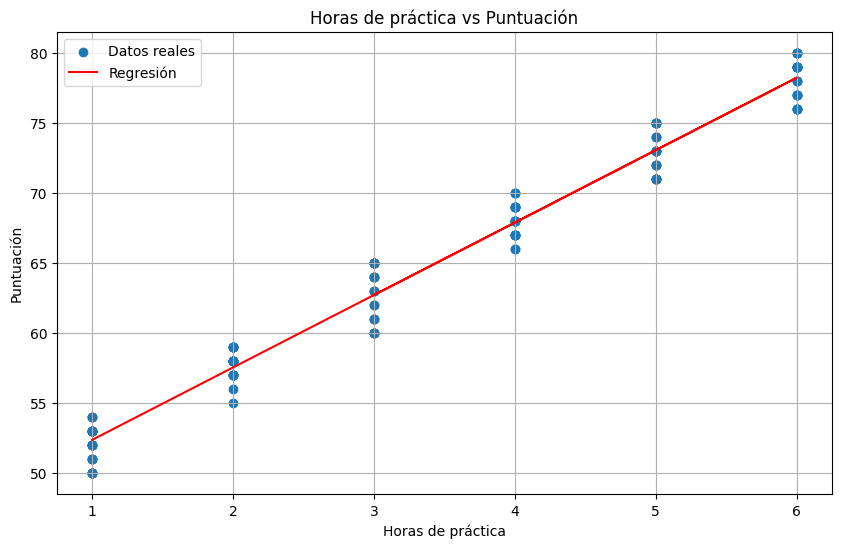

In [24]:
plt.figure(figsize=(10,6))
plt.scatter(X, Y, label="Datos reales")
plt.plot(X,modelo.predict(X), color="red", label="Regresión")
plt.title("Horas de práctica vs Puntuación")
plt.xlabel("Horas de práctica")
plt.ylabel("Puntuación")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
horas_ejemplo = np.array([[1],[3],[5]])

for horas in horas_ejemplo:
  prediccion = modelo.predict(horas.reshape(-1,1))
  print(f"Prediccion para {horas[0]} horas de estudio: {prediccion[0][0]:.2f} puntos")

Prediccion para 1 horas de estudio: 52.38 puntos
Prediccion para 3 horas de estudio: 62.73 puntos
Prediccion para 5 horas de estudio: 73.08 puntos
